# Lab Experiment 7 - Random Forest Classifier
**Subject:** Machine Learning Theory and Practice | **Code:** E1CAB 613

**Dataset:** Dry Bean Dataset (OpenML ID: 44225)

In [ ]:
# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

## Task 1: Exploratory Data Analysis (EDA)

In [33]:
data = fetch_openml(data_id=44225, as_frame=True)
df = data.frame.copy()
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (10362, 15)
Target Column: MEMBERSHIP_STATUS


,MEMBERSHIP_NUMBER,MEMBERSHIP_TERM_YEARS,ANNUAL_FEES,MEMBER_MARITAL_STATUS,MEMBER_GENDER,MEMBER_ANNUAL_INCOME,MEMBER_OCCUPATION_CD,MEMBERSHIP_PACKAGE,MEMBER_AGE_AT_ISSUE,ADDITIONAL_MEMBERS,PAYMENT_MODE,AGENT_CODE,MEMBERSHIP_STATUS,START_DATE (YYYYMMDD),END_DATE (YYYYMMDD)
0,A00001,29,113125.0,M,M,25200000.0,1.0,TYPE-B,45,2,ANNUAL,477,INFORCE,20060914,NaN
1,A00002,38,112220.0,M,M,10339200.0,1.0,TYPE-B,36,3,QUARTERLY,255,INFORCE,20061102,NaN
2,A00003,12,100000.0,M,M,14400000.0,1.0,TYPE-B,42,1,ANNUAL,7866,INFORCE,20070124,NaN
3,A00004,12,100000.0,M,M,9000000.0,1.0,TYPE-B,39,2,ANNUAL,200533,INFORCE,20070122,NaN
4,A00005,46,100000.0,M,M,4800000.0,1.0,TYPE-B,27,2,QUARTERLY,6988,INFORCE,20070131,NaN


Class Distribution:
MEMBERSHIP_STATUS
INFORCE      7219
CANCELLED    3143
Name: count, dtype: int64


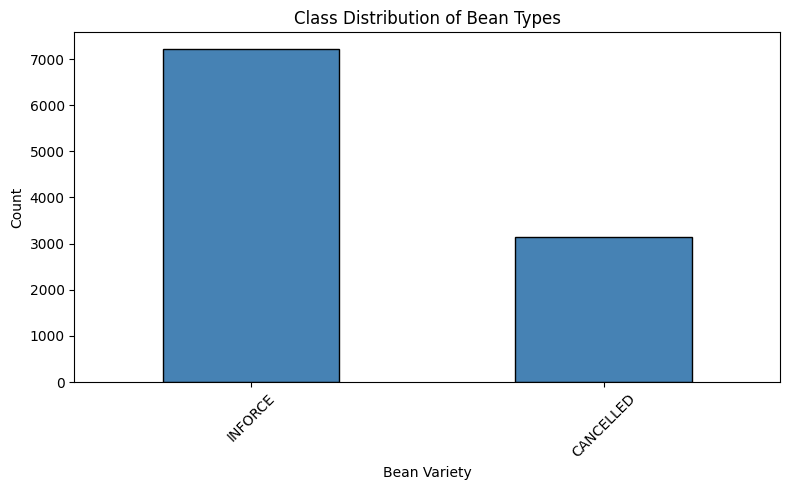

In [34]:
print(df['Class'].value_counts())
df['Class'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

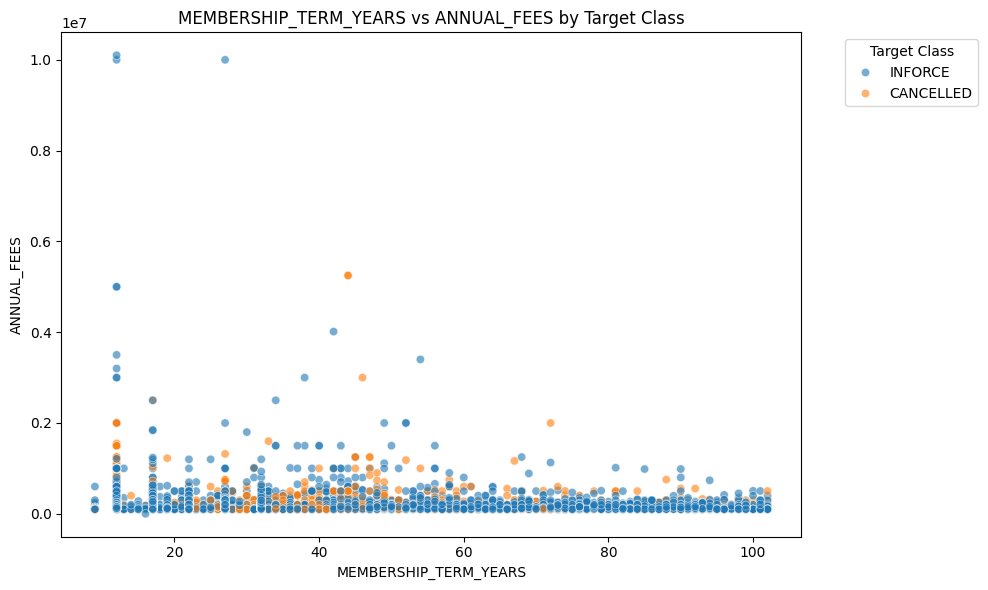

In [35]:
x_col, y_col = 'Area', 'Perimeter'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=x_col, y=y_col, hue='Class', alpha=0.6, palette='tab10')
plt.title('Area vs Perimeter by Class')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Task 2: Data Cleaning & Transformation

In [36]:
print('Missing Values per Column:')
print(df.isnull().sum())

print('\nData Types:')
print(df.dtypes)

Missing Values per Column:
MEMBERSHIP_NUMBER           0
MEMBERSHIP_TERM_YEARS       0
ANNUAL_FEES                 0
MEMBER_MARITAL_STATUS    2597
MEMBER_GENDER             611
MEMBER_ANNUAL_INCOME     1754
MEMBER_OCCUPATION_CD       43
MEMBERSHIP_PACKAGE          0
MEMBER_AGE_AT_ISSUE         0
ADDITIONAL_MEMBERS          0
PAYMENT_MODE                0
AGENT_CODE                  0
MEMBERSHIP_STATUS           0
START_DATE (YYYYMMDD)       0
END_DATE  (YYYYMMDD)     7219
dtype: int64

Data Types:
MEMBERSHIP_NUMBER            str
MEMBERSHIP_TERM_YEARS      int64
ANNUAL_FEES              float64
MEMBER_MARITAL_STATUS        str
MEMBER_GENDER                str
MEMBER_ANNUAL_INCOME     float64
MEMBER_OCCUPATION_CD     float64
MEMBERSHIP_PACKAGE           str
MEMBER_AGE_AT_ISSUE        int64
ADDITIONAL_MEMBERS         int64
PAYMENT_MODE                 str
AGENT_CODE                   str
MEMBERSHIP_STATUS            str
START_DATE (YYYYMMDD)      int64
END_DATE  (YYYYMMDD)     float64
dt

In [44]:
df = df.drop_duplicates().fillna(df.median(numeric_only=True))
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
print('Cleaned Dataset Shape:', df.shape)

Duplicates before: 0
Duplicates after: 0

Missing Values After Cleaning:
MEMBERSHIP_TERM_YEARS    0
ANNUAL_FEES              0
MEMBER_MARITAL_STATUS    0
MEMBER_GENDER            0
MEMBER_ANNUAL_INCOME     0
MEMBER_OCCUPATION_CD     0
MEMBERSHIP_PACKAGE       0
MEMBER_AGE_AT_ISSUE      0
ADDITIONAL_MEMBERS       0
PAYMENT_MODE             0
AGENT_CODE               0
MEMBERSHIP_STATUS        0
START_DATE (YYYYMMDD)    0
END_DATE  (YYYYMMDD)     0
Class_encoded            0
dtype: int64

Class Mapping:
  CANCELLED -> 0
  INFORCE -> 1

Number of Features: 13
Cleaned Dataset Shape: (10362, 15)


## Task 3: Model Building

In [45]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (8289, 4338)
Testing set size: (2073, 4338)


In [46]:
rf = RandomForestClassifier(n_estimators=100, max_depth=3, bootstrap=True, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

print('Model trained successfully!')
print(f'OOB Score: {rf.oob_score_:.4f}')

Model trained successfully!
OOB Score (Out-of-Bag Accuracy): 0.6717


## Task 4: Model Evaluation

In [47]:
y_pred = rf.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Test Accuracy: 0.6710


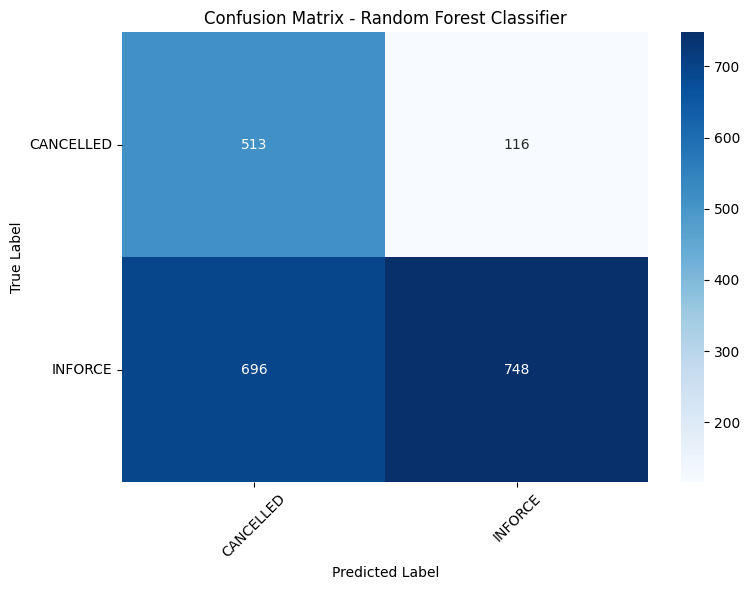

In [41]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [48]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

   CANCELLED       0.48      0.82      0.60       629
     INFORCE       0.89      0.61      0.72      1444

    accuracy                           0.67      2073
   macro avg       0.68      0.71      0.66      2073
weighted avg       0.76      0.67      0.68      2073



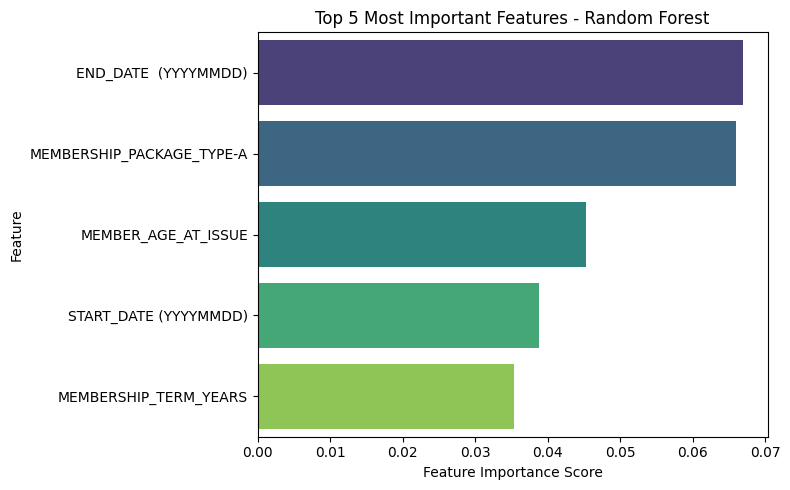

Top 5 Features:
  END_DATE  (YYYYMMDD): 0.0670
  MEMBERSHIP_PACKAGE_TYPE-A: 0.0659
  MEMBER_AGE_AT_ISSUE: 0.0452
  START_DATE (YYYYMMDD): 0.0387
  MEMBERSHIP_TERM_YEARS: 0.0354


In [49]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:5]
top_features = X.columns[idx]
top_values = importances[idx]

plt.figure(figsize=(8, 5))
sns.barplot(x=top_values, y=top_features, hue=top_features, palette='viridis', dodge=False, legend=False)
plt.title('Top 5 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 5 Features:')
for name, val in zip(top_features, top_values):
    print(f'  {name}: {val:.4f}')